# 04 — Comparison: RQ-KMeans vs PSE/OPQ

Side-by-side evaluation of both SID assignment methods.

In [1]:
DRY_RUN = False

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from src.data.yambda_loader import load_embeddings
from src.tokenizers.rq_kmeans import RQKMeans
from src.tokenizers.pse_opq import PSETokenizer
from src.evaluation.metrics import summarize_metrics, plot_comparison

In [3]:
with open("../configs/default.yaml") as f:
    config = yaml.safe_load(f)

suffix = "_dryrun" if DRY_RUN else ""
rq_cfg = config["rq_kmeans"]
pse_cfg = config["pse_opq"]

rq_codebook_width = min(32, rq_cfg["codebook_width"]) if DRY_RUN else rq_cfg["codebook_width"]
pse_codebook_size = min(32, pse_cfg["codebook_size"]) if DRY_RUN else pse_cfg["codebook_size"]

## Load Data & Models

In [4]:
# Load embeddings
embed_path = config["data"]["output_path"].replace(".parquet", f"{suffix}.parquet")
item_ids, embeddings = load_embeddings(embed_path)

# Load RQ-KMeans SIDs & model
rq_sids_df = pd.read_parquet(rq_cfg["sids_path"].replace(".parquet", f"{suffix}.parquet"))
rq_sid_cols = sorted([c for c in rq_sids_df.columns if c.startswith("sid_")],
                     key=lambda c: int(c.split("_")[1]))
rq_sids = rq_sids_df[rq_sid_cols].values.astype(np.int32)

rq_model = RQKMeans.load(rq_cfg["checkpoint_path"].replace(".pt", f"{suffix}.pt"))
rq_reconstructed = rq_model.reconstruct(embeddings)

# Load PSE SIDs & model
pse_sids_df = pd.read_parquet(pse_cfg["sids_path"].replace(".parquet", f"{suffix}.parquet"))
pse_sid_cols = sorted([c for c in pse_sids_df.columns if c.startswith("sid_")],
                      key=lambda c: int(c.split("_")[1]))
pse_sids = pse_sids_df[pse_sid_cols].values.astype(np.int32)

pse_model = PSETokenizer.load(pse_cfg["index_path"].replace(".faiss", f"{suffix}.faiss"))
pse_reconstructed = pse_model.reconstruct(embeddings)

print(f"RQ-KMeans SIDs: {rq_sids.shape}, PSE SIDs: {pse_sids.shape}")

Loaded 500000 embeddings of dim 128 from data/embeddings.parquet
RQ-KMeans loaded from outputs/rq_kmeans/model.pt


PSE index loaded from outputs/pse_opq/index.faiss


RQ-KMeans SIDs: (500000, 10), PSE SIDs: (500000, 10)


## Compute Metrics

In [5]:
results_rq = summarize_metrics("RQ-KMeans", rq_sids, embeddings,
                                rq_reconstructed, rq_codebook_width)
results_pse = summarize_metrics("PSE/OPQ", pse_sids, embeddings,
                                 pse_reconstructed, pse_codebook_size)

In [6]:
# Summary table
summary = pd.DataFrame({
    "Metric": ["Reconstruction MSE", "Codebook Utilization (mean)",
               "Collision Rate", "Entropy (mean)"],
    "RQ-KMeans": [
        f"{results_rq['reconstruction_mse']:.6f}",
        f"{results_rq['codebook_utilization_mean']:.4f}",
        f"{results_rq['collision_rate']:.6f}",
        f"{results_rq['entropy_mean']:.4f}",
    ],
    "PSE/OPQ": [
        f"{results_pse['reconstruction_mse']:.6f}",
        f"{results_pse['codebook_utilization_mean']:.4f}",
        f"{results_pse['collision_rate']:.6f}",
        f"{results_pse['entropy_mean']:.4f}",
    ],
})
print(summary.to_string(index=False))

                     Metric RQ-KMeans  PSE/OPQ
         Reconstruction MSE  0.005547 0.000830
Codebook Utilization (mean)    1.0000   1.0000
             Collision Rate  0.010918 0.026098
             Entropy (mean)    0.9981   0.9933


## Comparison Plots

In [7]:
output_dir = config["evaluation"]["output_dir"]
if DRY_RUN:
    output_dir = output_dir + "_dryrun"

plot_comparison(results_rq, results_pse, output_dir,
                config["evaluation"]["plot_format"])

Plots saved to outputs/comparison



codebook_utilization:


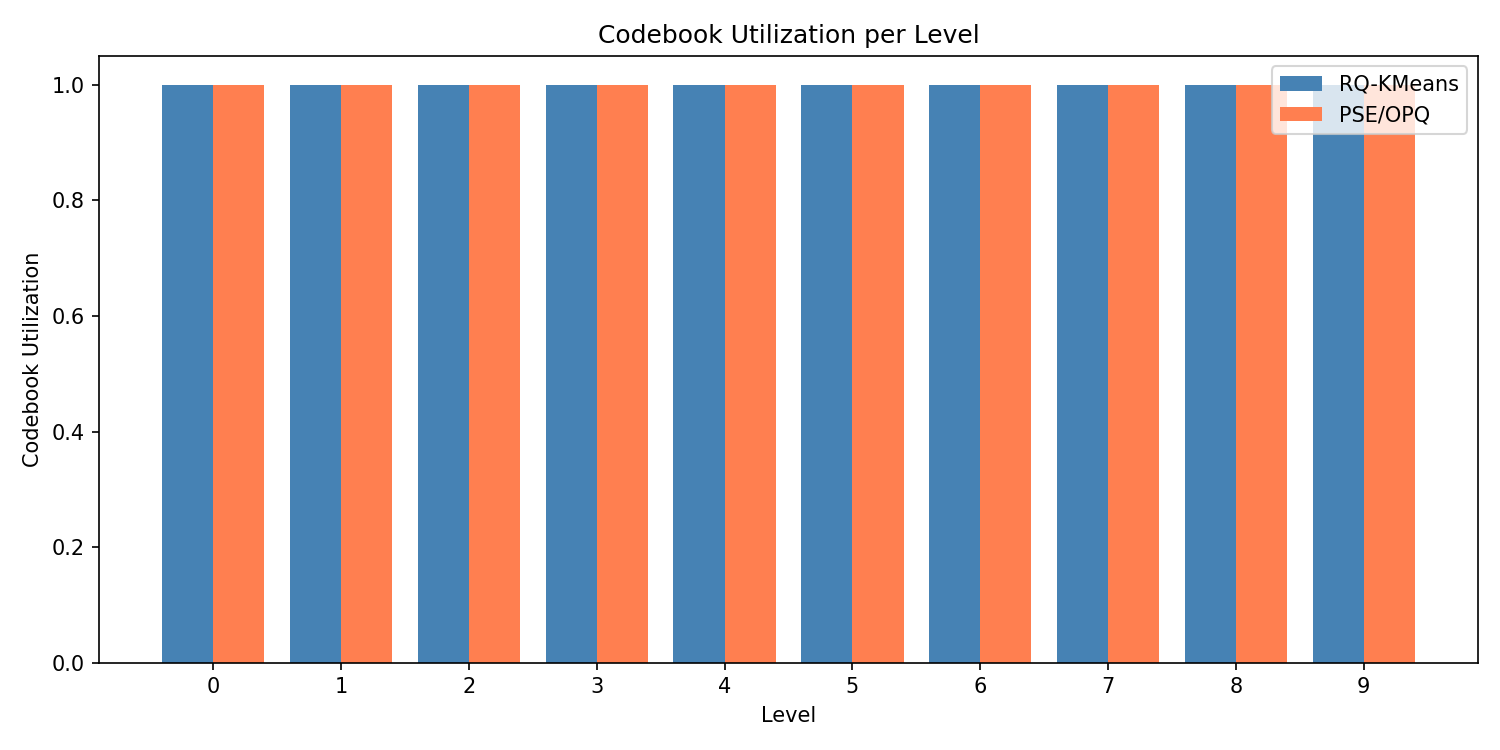


entropy:


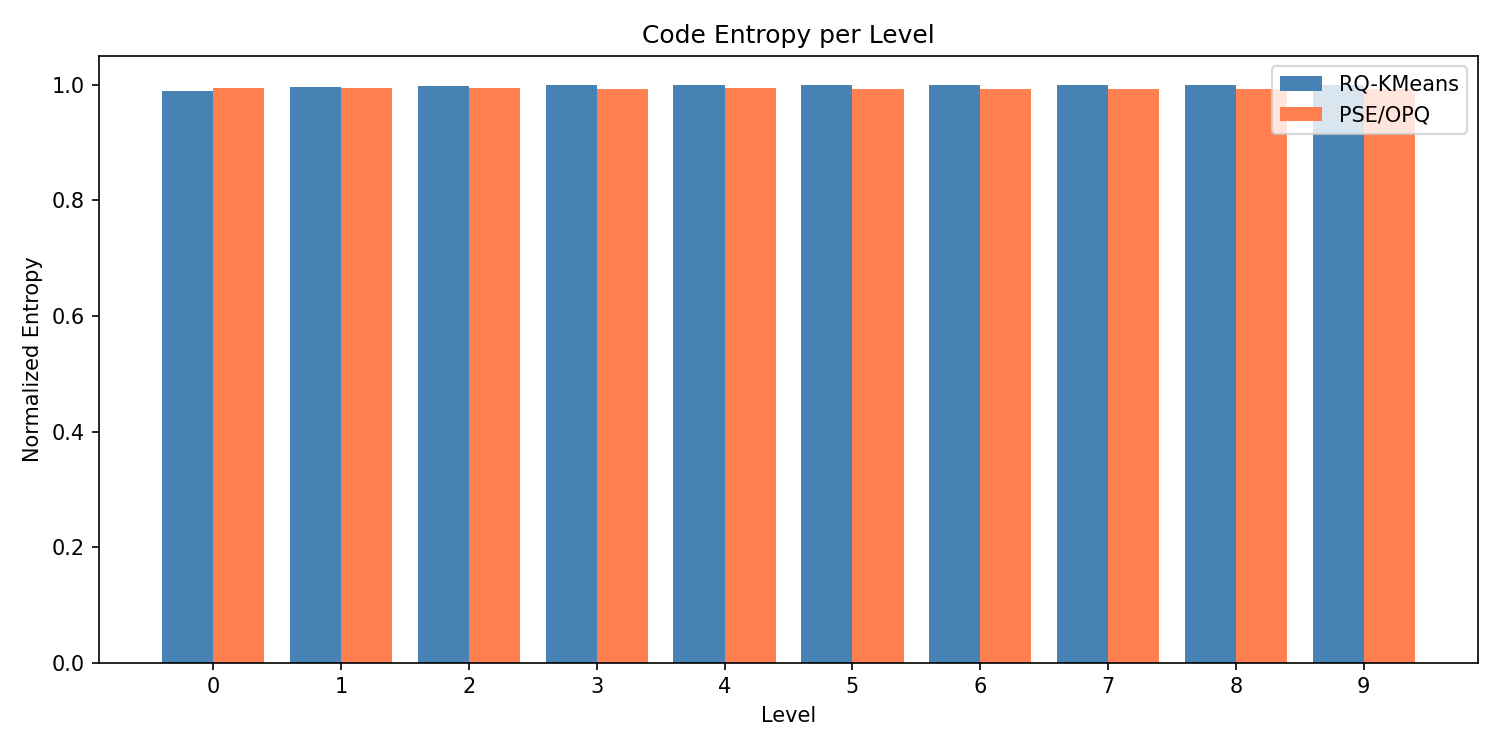


reconstruction_mse:


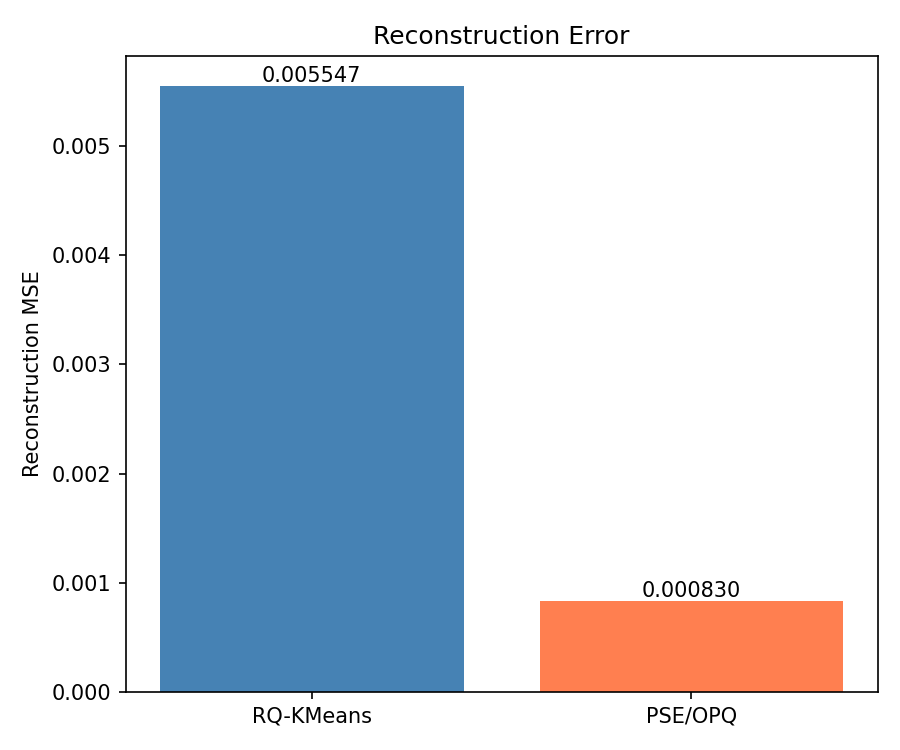


summary:


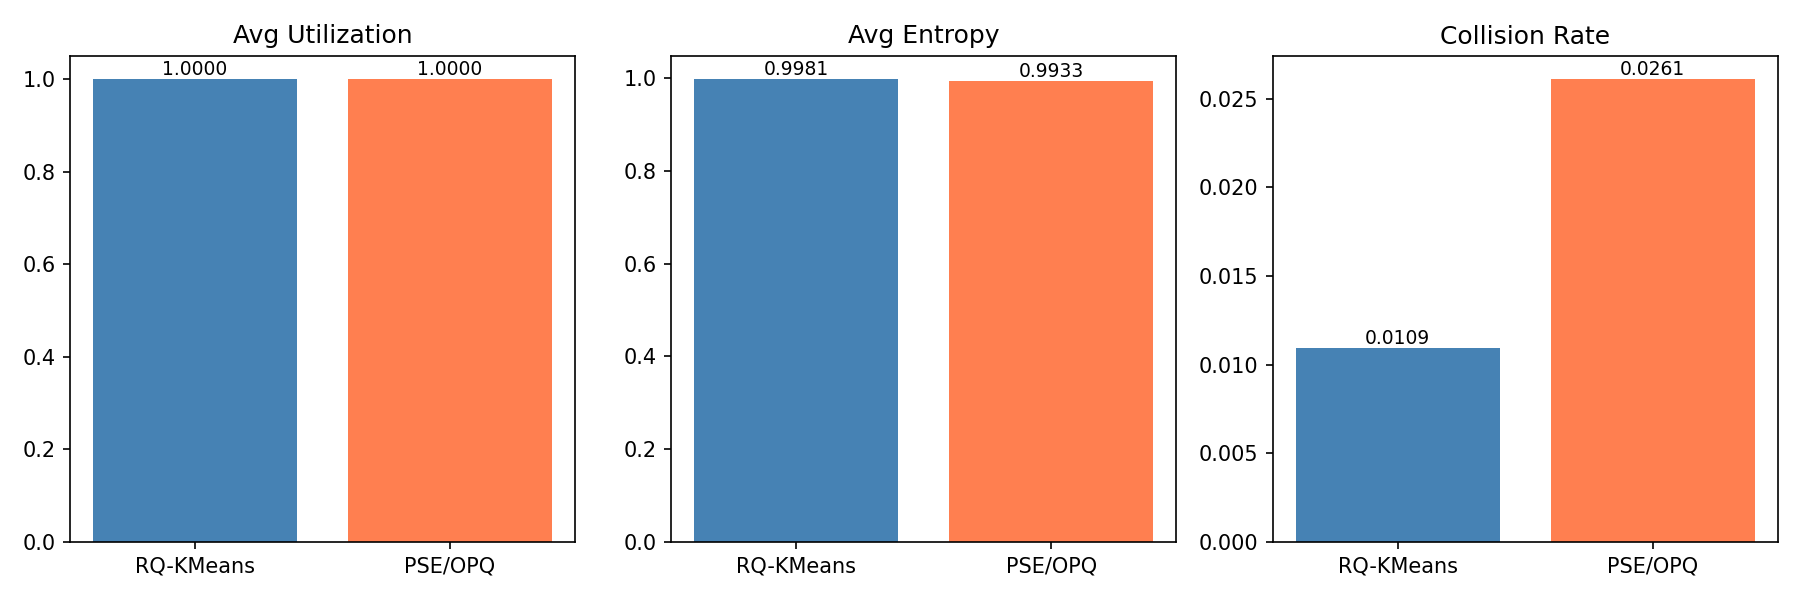

In [8]:
# Display plots inline
from pathlib import Path
from IPython.display import Image, display

fmt = config["evaluation"]["plot_format"]
for plot_name in ["codebook_utilization", "entropy", "reconstruction_mse", "summary"]:
    plot_path = Path(output_dir) / f"{plot_name}.{fmt}"
    if plot_path.exists():
        print(f"\n{plot_name}:")
        display(Image(filename=str(plot_path)))

In [9]:
# Save results JSON
import json
results_path = Path(output_dir) / "results.json"
with open(results_path, "w") as f:
    json.dump({"rq_kmeans": results_rq, "pse_opq": results_pse}, f, indent=2)
print(f"Results saved to {results_path}")

Results saved to outputs/comparison/results.json
